In [5]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_percentage_error
import matplotlib.pyplot as plt

In [38]:
# -----------------------------
# Configuration
# -----------------------------
CSV_FILE = "energy_with_temp.csv"  # your CSV
VALUE_COL = "P_HOME"
LAGS = [1,2,3,6,12,24,48,168] # previous hours to use as features

# -----------------------------
# Load data
# -----------------------------
df = pd.read_csv(CSV_FILE, sep=";", parse_dates=["TimeStamp"])
df = df.set_index("TimeStamp")

df = df.loc["2026-01-01":"2026-02-23"]
df["hour"] = df.index.hour
df["rolling_3h"] = df[VALUE_COL].rolling(3).mean()
df["rolling_6h"] = df[VALUE_COL].rolling(6).mean()
df["rolling_24h"] = df[VALUE_COL].rolling(24).mean()


# Lag features
for lag in LAGS:
    df[f"lag_{lag}"] = df[VALUE_COL].shift(lag)

# Drop rows with NaNs from lag features
df = df.dropna()
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])
# Features and target
X = df.drop(columns=[VALUE_COL])
y = df[VALUE_COL]

# -----------------------------
# Train-test split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.4, shuffle=False
)

In [39]:
# -----------------------------
# XGBoost Model
# -----------------------------
model = xgb.XGBRegressor(
    objective="reg:squarederror",
    random_state=42
)

# Parameter search space
param_grid = {
    "n_estimators": [200, 400, 600],
    "max_depth": [3,5,7,10],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.7,0.8,1],
    "colsample_bytree": [0.7,0.8,1],
    "gamma": [0,0.1,0.2],
}

# Time-series cross validation
tscv = TimeSeriesSplit(n_splits=3)

search = RandomizedSearchCV(
    model,
    param_grid,
    n_iter=20,
    cv=tscv,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    verbose=1
)

search.fit(X_train, y_train)

best_model = search.best_estimator_

print("Best parameters:", search.best_params_)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best parameters: {'subsample': 0.7, 'n_estimators': 600, 'max_depth': 3, 'learning_rate': 0.05, 'gamma': 0, 'colsample_bytree': 1}


MAPE: 10.12%


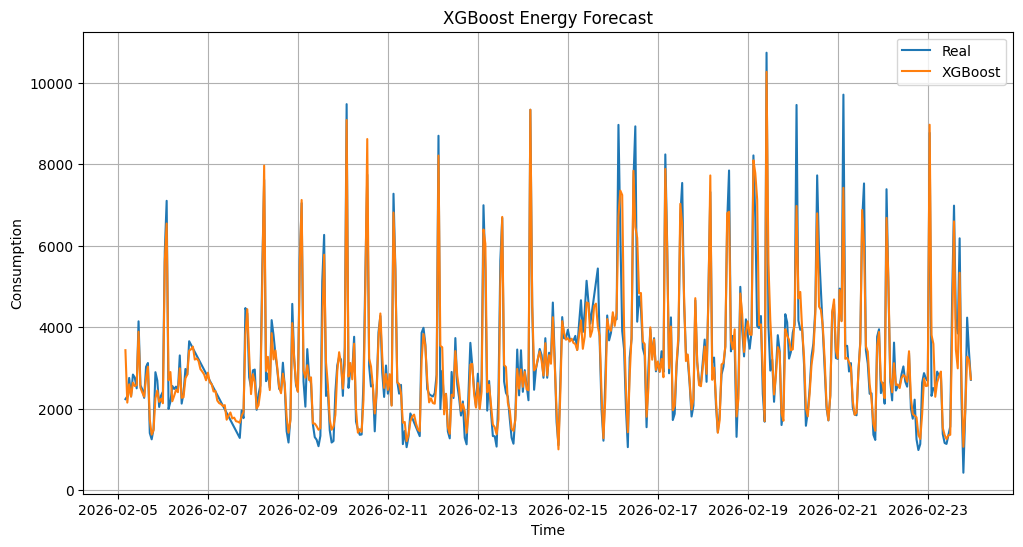

In [40]:
# -----------------------------
# Predict
# -----------------------------
y_pred = best_model.predict(X_test)

# -----------------------------
# Accuracy
# -----------------------------
mape = mean_absolute_percentage_error(y_test, y_pred) * 100
print(f"MAPE: {mape:.2f}%")

# -----------------------------
# Plot results
# -----------------------------
plt.figure(figsize=(12,6))

plt.plot(y_test.index, y_test.values, label="Real")
plt.plot(y_test.index, y_pred, label="XGBoost")

plt.title("XGBoost Energy Forecast")
plt.xlabel("Time")
plt.ylabel("Consumption")

plt.legend()
plt.grid(True)

plt.show()

<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

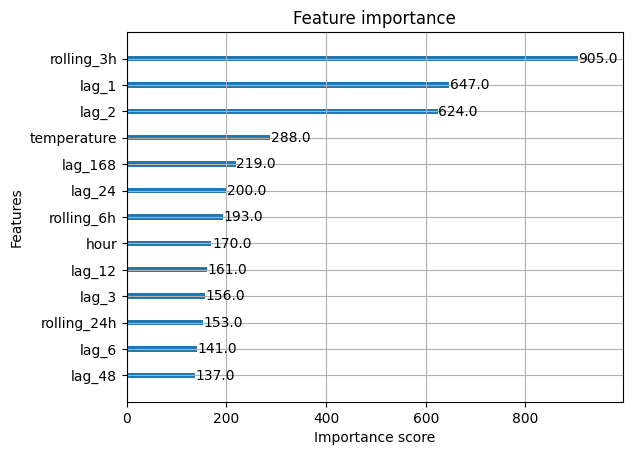

In [41]:
xgb.plot_importance(best_model)

In [42]:
import pandas as pd
import numpy as np


# # -----------------------------
# # Load data
# # -----------------------------
# df = pd.read_csv(CSV_FILE, sep=";", parse_dates=["TimeStamp"])
# df = df.set_index("TimeStamp")

# df = df.loc["2026-03-02":"2026-03-12"]
# df["hour"] = df.index.hour
# df["rolling_3h"] = df[VALUE_COL].rolling(3).mean()
# df["rolling_6h"] = df[VALUE_COL].rolling(6).mean()
# df["rolling_24h"] = df[VALUE_COL].rolling(24).mean()


# # Lag features
# for lag in LAGS:
#     df[f"lag_{lag}"] = df[VALUE_COL].shift(lag)

# # Drop rows with NaNs from lag features
# df = df.dropna()

# # Features and target
# X = df.drop(columns=[VALUE_COL])
# y = df[VALUE_COL]


FORECAST_HOURS = 24
last_data = df.copy()
predictions = []

# List of feature columns used for training
FEATURE_COLS = [
    "temperature","hour",
    "rolling_3h", "rolling_6h", "rolling_24h",
    "lag_1", "lag_2", "lag_3", "lag_6", "lag_12", "lag_24", "lag_48", "lag_168"
]

for i in range(FORECAST_HOURS):
    next_time = last_data.index[-1] + pd.Timedelta(hours=1)
    
    # Build new row
    new_row = {}
    new_row["hour"] = next_time.hour
    new_row["temperature"] = last_data["temperature"].iloc[-1]  # can replace with forecast
    
    # Short-term lag features (recursive)
    new_row["lag_1"] = last_data[VALUE_COL].iloc[-1]
    new_row["lag_2"] = last_data[VALUE_COL].iloc[-2]
    new_row["lag_3"] = last_data[VALUE_COL].iloc[-3]
    new_row["lag_6"] = last_data[VALUE_COL].iloc[-6]
    new_row["lag_12"] = last_data[VALUE_COL].iloc[-12]
    
    # Long-term lag features (historical)
    new_row["lag_24"] = last_data[VALUE_COL].iloc[-24]
    new_row["lag_48"] = last_data[VALUE_COL].iloc[-48]
    new_row["lag_168"] = last_data[VALUE_COL].iloc[-168]
    
    # Rolling features (recursive)
    new_row["rolling_3h"] = last_data[VALUE_COL].iloc[-3:].mean()
    new_row["rolling_6h"] = last_data[VALUE_COL].iloc[-6:].mean()
    new_row["rolling_24h"] = last_data[VALUE_COL].iloc[-24:].mean()
    
    # Convert to DataFrame with correct column order
    X_new = pd.DataFrame([new_row], columns=FEATURE_COLS)
    
    # Predict
    y_pred = best_model.predict(X_new)[0]
    predictions.append(y_pred)
    
    # Append predicted consumption for next recursive step
    new_row[VALUE_COL] = y_pred
    new_row_df = pd.DataFrame([new_row], index=[next_time])
    last_data = pd.concat([last_data, new_row_df])

# Build forecast DataFrame
forecast_index = pd.date_range(
    start=df.index[-1] + pd.Timedelta(hours=1),
    periods=FORECAST_HOURS,
    freq="H"
)

forecast_df = pd.DataFrame({
    "forecast": predictions
}, index=forecast_index)

print(forecast_df.head())


                        forecast
2026-02-24 00:00:00  3895.457031
2026-02-24 01:00:00  3307.903076
2026-02-24 02:00:00  3015.152832
2026-02-24 03:00:00  3709.477783
2026-02-24 04:00:00  3104.431885


C:\Users\hp\AppData\Local\Temp\ipykernel_103788\4045158272.py:79: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  forecast_index = pd.date_range(


MAPE: 86.82%


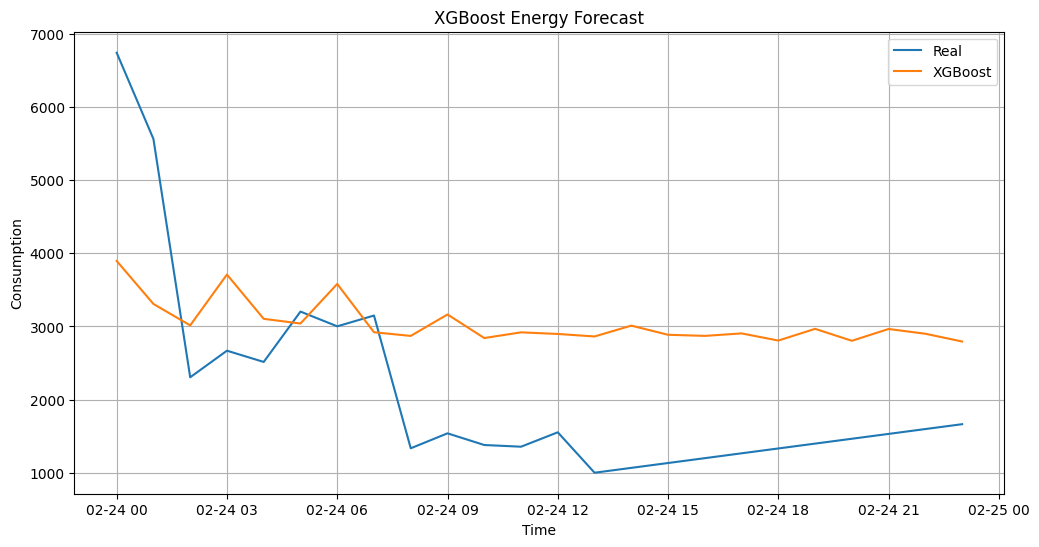

In [43]:
checkDF = pd.read_csv(CSV_FILE, sep=";", parse_dates=["TimeStamp"])
checkDF = checkDF.set_index("TimeStamp")

checkDF = checkDF.loc["2026-02-24"]
real_y = checkDF[VALUE_COL]

# -----------------------------
# Accuracy
# -----------------------------
mape = mean_absolute_percentage_error(real_y, forecast_df) * 100
print(f"MAPE: {mape:.2f}%")

# -----------------------------
# Plot results
# -----------------------------
plt.figure(figsize=(12,6))

plt.plot(real_y.index, real_y.values, label="Real")
plt.plot(real_y.index, forecast_df, label="XGBoost")

plt.title("XGBoost Energy Forecast")
plt.xlabel("Time")
plt.ylabel("Consumption")

plt.legend()
plt.grid(True)

plt.show()